### Meanshift

In [134]:
import numpy as np
import cv2
from sklearn.cluster import MeanShift
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
import os

In [135]:
def convert_color_space(img, color_space):
    if color_space == "rgb":
        return img
    if color_space == "gray":
        return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    if color_space == "hsv":
        return cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    if color_space == "lab":
        return cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    raise ValueError(color_space)

def equalize_image(img):
    if img.ndim == 2:
        return cv2.equalizeHist(img)
    ch = cv2.split(img)
    ch = [cv2.equalizeHist(c) for c in ch]
    return cv2.merge(ch)

def clahe_image(img, clip=2.0, grid=(8,8)):
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=grid)
    if img.ndim == 2:
        return clahe.apply(img)
    ch = cv2.split(img)
    ch = [clahe.apply(c) for c in ch]
    return cv2.merge(ch)

def preprocess_charcoal_image(img):
    out = convert_color_space(img, "lab")
    out = clahe_image(out)
    return out

In [136]:
def denoise(img, method=None, g_sigma=1.0, m_ksize=5):
    if method is None:
        return img
    if method == "gaussian":
        k = int(g_sigma*6+1)|1
        return cv2.GaussianBlur(img,(k,k),g_sigma)
    if method == "median":
        if m_ksize % 2 == 0:
            m_ksize += 1
        return cv2.medianBlur(img, m_ksize)
    raise ValueError(method)

In [137]:
def region_boundaries(labels):
    h, w = labels.shape
    boundaries = np.zeros((h, w), dtype=np.uint8)
    for y in range(h - 1):
        for x in range(w - 1):
            if labels[y, x] != labels[y, x + 1] or labels[y, x] != labels[y + 1, x]:
                boundaries[y, x] = 255
    return boundaries

In [138]:
def apply_meanshift(img, spatial_radius=10, color_radius=10):
    h, w = img.shape[:2]

    xs, ys = np.meshgrid(np.arange(w), np.arange(h))

    features = np.column_stack((
        xs.flatten(),
        ys.flatten(),
        img.reshape(-1, 3)
    )).astype(np.float32)

    features[:, 0:2] /= spatial_radius
    features[:, 2:5] /= color_radius

    ms = MeanShift(bandwidth=1.0, bin_seeding=True)
    labels = ms.fit_predict(features)
    labels_img = labels.reshape(h, w)

    print(f"{len(np.unique(labels))} different regions")

    segmented = np.zeros_like(img)
    for lab in np.unique(labels_img):
        mask = labels_img == lab
        segmented.reshape(-1, img.shape[2])[mask.flatten()] = img.reshape(-1, img.shape[2])[mask.flatten()].mean(axis=0)

    boundaries = region_boundaries(labels_img)
    result = segmented.copy()
    result[boundaries == 255] = 0

    return segmented, result, len(np.unique(labels))

In [139]:
def preprocess_img(img_path, x1,y1,x2,y2):
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    cropped_img = img_rgb[y1:y2, x1:x2]
    preprocessed_img = preprocess_charcoal_image(cropped_img)
    return preprocessed_img

In [147]:
def evaluate_meanshift_params(imgs_path_list, crops_coordinates_list, ks_range, kr_range, output_dir):
    
    os.makedirs(output_dir, exist_ok=True)

    for i, img_path in enumerate(imgs_path_list):

        print(f"Processing image {img_path}")

        img_name = os.path.splitext(os.path.basename(img_path))[0]
        img_out_dir = os.path.join(output_dir, f"{img_name}")
        os.makedirs(img_out_dir, exist_ok=True)

        x1, y1, x2, y2 = crops_coordinates_list[i]
        img = preprocess_img(img_path, x1, y1, x2, y2)
        img=denoise(img, method="median", m_ksize=2)

        h, w, _ = img.shape
        ks_range=np.array(ks_range)*((h*w)/68000)

        for ks in ks_range:
            for kr in kr_range:
                print(f"ks={ks}, kr={kr}")
                segmented, result, nb_regions = apply_meanshift(img, spatial_radius=ks, color_radius=kr)
                filename = f"ms_ks{int(ks)}_kr{int(kr)}_{nb_regions}regions.png"
                save_path = os.path.join(img_out_dir, filename)
                segmented_bgr = cv2.cvtColor(segmented, cv2.COLOR_LAB2BGR)
                cv2.imwrite(save_path, segmented_bgr)

In [149]:
imgs_path_list=[ '../dataset/lascaux/Lascaux_021.jpg'] #'../dataset/cosquer/panneau_des_cheveaux.jpg', '../dataset/mains/Cueva_de_las_manos_-_detalle.jpg',
crops_coordinates_list=[[402,198,923,669]]#[100,375,543,682],[955,548,1153,734],
ks_range=[16,24,32,40,48]
kr_range=[8,16,24,32,40,48]
output_dir="meanshift_results"

evaluate_meanshift_params(imgs_path_list,crops_coordinates_list, ks_range, kr_range, output_dir)

Processing image ../dataset/lascaux/Lascaux_021.jpg
ks=57.73905882352941, kr=8
241 different regions
ks=57.73905882352941, kr=16
59 different regions
ks=57.73905882352941, kr=24
33 different regions
ks=57.73905882352941, kr=32
29 different regions
ks=57.73905882352941, kr=40
23 different regions
ks=57.73905882352941, kr=48
19 different regions
ks=86.60858823529412, kr=8
101 different regions
ks=86.60858823529412, kr=16
28 different regions
ks=86.60858823529412, kr=24
15 different regions
ks=86.60858823529412, kr=32
11 different regions
ks=86.60858823529412, kr=40
10 different regions
ks=86.60858823529412, kr=48
10 different regions
ks=115.47811764705882, kr=8
54 different regions
ks=115.47811764705882, kr=16
12 different regions
ks=115.47811764705882, kr=24
11 different regions
ks=115.47811764705882, kr=32
9 different regions
ks=115.47811764705882, kr=40
8 different regions
ks=115.47811764705882, kr=48
6 different regions
ks=144.34764705882353, kr=8
33 different regions
ks=144.34764705

#### Meanshift, brouillon

In [132]:
preprocessed_img=preprocess_img("../dataset/cosquer/panneau_des_cheveaux.jpg", 100, 375, 543, 682)
# preprocessed_img=cv2.resize(preprocessed_img, (443//2, 307//2))
preprocessed_img=denoise(preprocessed_img, method="median", m_ksize=2)

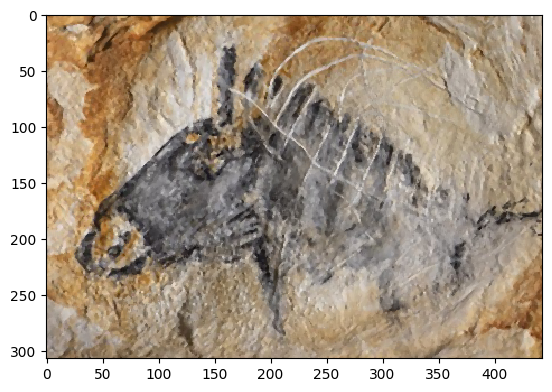

In [133]:
# rgb = cv2.cvtColor(preprocessed_img, cv2.COLOR_BGR2RGB)
rgb=preprocessed_img
plt.imshow(rgb,interpolation='nearest')
plt.show()

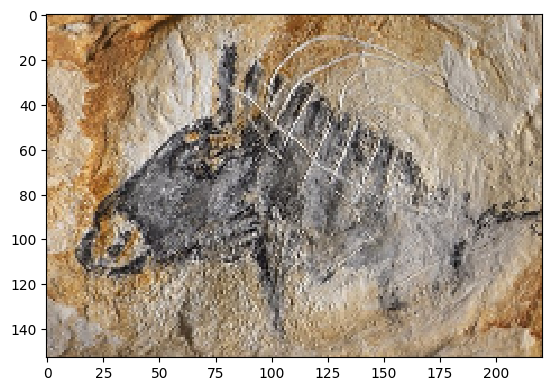

In [127]:
# rgb = cv2.cvtColor(preprocessed_img, cv2.COLOR_BGR2RGB)
rgb=preprocessed_img
plt.imshow(rgb,interpolation='nearest')
plt.show()

In [128]:
segmented, result = apply_meanshift(preprocessed_img, spatial_radius=40, color_radius=40)

9 different regions


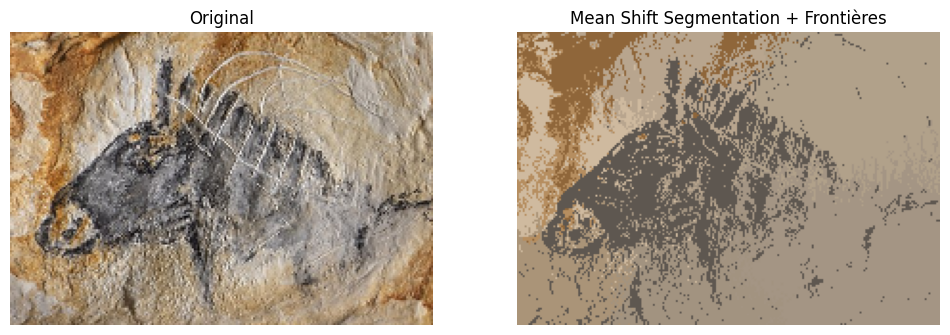

In [129]:
# result_rgb = cv2.cvtColor(result, cv2.COLOR_LAB2RGB)
# segmented_rgb = cv2.cvtColor(segmented, cv2.COLOR_LAB2RGB)
result_rgb=result
segmented_rgb=segmented
preprocessed_img_rgb = cv2.cvtColor(preprocessed_img, cv2.COLOR_LAB2RGB)
preprocessed_img_rgb = preprocessed_img
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(preprocessed_img_rgb)
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(segmented_rgb)
plt.title("Mean Shift Segmentation + Frontières")
plt.axis('off')

plt.show()

### Morphological Geodesic Active Contours

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.filters import gaussian, sobel
from skimage.segmentation import morphological_geodesic_active_contour
from skimage.draw import polygon
from scipy.interpolate import splprep, splev
from skimage.measure import find_contours
from skimage.segmentation import inverse_gaussian_gradient

In [ ]:
preprocessed_img=preprocess_img("../dataset/cosquer/panneau_des_cheveaux.jpg", 100, 375, 543, 682)
# preprocessed_img=cv2.resize(preprocessed_img, (443//2, 307//2))
preprocessed_img=denoise(preprocessed_img, method="median", m_ksize=2)

In [ ]:
gimage = inverse_gaussian_gradient(preprocessed_img)
init_ls = np.zeros(preprocessed_img.shape, dtype=np.int8)
init_ls[10:-10, 10:-10] = 1

snake_mask = morphological_geodesic_active_contour(
    gimage,
    num_iter=230,
    init_level_set=init_ls,
    smoothing=1,
    balloon=-1
)

contours = find_contours(snake_mask, level=0.5)
fig, ax = plt.subplots(figsize=(7,7))
ax.imshow(cv2.cvtColor(preprocessed_img, cv2.COLOR_LAB2RGB))
for contour in contours:
    ax.plot(contour[:,1], contour[:,0], '-b', lw=2)
ax.set_title("MGAC après preprocessing")
ax.axis('off')
plt.show()